## CitySeer: Métricas Configuracionais do Espaço Urbano

**AUTORIA:** [REDE MOB](https://www.redemob.com.br/), com base nos [notebooks ilustrativos do pacote cityseer](https://benchmark-urbanism.github.io/cityseer-examples/).

`cityseer-api` é uma ferramenta digital desenvolvida para ajudar na análise detalhada de ruas e do uso do solo nas cidades. Seu principal objetivo é compreender como a forma urbana influencia a vitalidade dos bairros, especialmente do ponto de vista de quem anda a pé.

Com essa ferramenta, é possível medir a importância de diferentes ruas dentro da rede viária, avaliar o acesso a diferentes tipos de uso do solo (como moradia, comércio, serviços), e entender como essas relações espaciais se organizam dentro de um bairro ou cidade. As análises levam em conta a distância real de caminhada e a direção pela qual as pessoas se aproximam de cada lugar, oferecendo uma visão mais precisa da acessibilidade urbana.

Além disso, o `cityseer-api` permite trabalhar com dados de mapas abertos e pode ser usado para analisar cidades pequenas ou grandes. Ele ajuda planejadores urbanos, arquitetos e pesquisadores a entenderem melhor como o desenho das ruas e a distribuição dos usos do solo influenciam a dinâmica dos espaços urbanos.

**PANORAMA**
- Análises espaciais de alta resolução, com janelas móveis locais e distâncias reais de rede, para maior sensibilidade ao contexto urbano.

- Cálculo local de centralidades de rede, com caminhos mais curtos ou simples, incluindo variantes contínuas e métricas específicas como harmonic closeness.

- Medições de acessibilidade e uso misto do solo, com agregações dinâmicas e direcionais, adaptáveis a diferentes estruturas de rede.

- Integração de centralidade, acessibilidade e estatísticas, gerando dados multivariados úteis para ciência de dados e aprendizado de máquina.

- Limpeza da rede, para reduzir distorções topológicas e melhorar a precisão analítica.

- Desempenho otimizado, permitindo análise eficiente de redes grandes e detalhadas.

**MAIS INFORMAÇÕES:**
- **Importante**: a biblioteca foi concebida com ênfase em pedestres, de maneira que ela não leva em conta a direcionalidade da rede, mas, em cidades como o Rio de Janeiro, por exemplo, há muitas vias de mão única, o que pode em alguma medida distorcer o resultado das métricas em algum contexto. Para pedestres, isso não seria um problema, dado que eles não estão confinados ao sentido do tráfego. No entanto, se a biblioteca for utilizada para compreender o ponto de vista dos usuários do automóvel, os resultados podem não ser tao precisos. Mas, como próximo de uma via de mão única normalmente há uma via em sentido contrário, em uma análise mais além do nível da vizinhança, os resultados devem ainda ser informativos.
        
    - **# TO DO**: computar betweenness na escala de uma grande regiã como uma Área de Planejamento do Rio de Janeiro para fazer uma espécie de benchmark dos resultados

**LINKS DE INTERESSE:**
- [Artigo de origem do cityseer](https://journals.sagepub.com/doi/full/10.1177/23998083221133827)
- Detalhes teóricos para os mais curiosos podem ser encontrados em uma vasta literatura técnica e acadêmica, mas, de início, pode ser interessante começar pelas [notas de aula do professor Romulo Krafta](https://www.researchgate.net/profile/Romulo-Krafta/publication/265597665_NOTAS_DE_AULA_DE_MORFOLOGIA_URBANA/links/58cfdeb7458515b6ed8c457f/NOTAS-DE-AULA-DE-MORFOLOGIA-URBANA.pdf), as quais foram transformadas em livro.

- **#TO DO**: mais links para materiais técnicos e acadêmicos gerais, externos, de referência a respeito do conteúdo abordado


# Instruções

yada yada yada

# Parâmetros Definidos Pelo Usuário

In [75]:
# Forneça código do IBGE da cidade, ou lista de códigos
MUNI_CODES      = (3300258, 3300209, 3301876, 3305208, 3300233, 3300704)

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [76]:
from libpysal.cg import voronoi_frames
from tobler.area_weighted import area_interpolate

In [77]:
# Standard library imports
from collections import defaultdict
from io import BytesIO
from itertools import combinations
from pathlib import Path
import pickle
import requests
import tempfile
from typing import List, Optional, Union
import zipfile

# Third-party library imports
from cityseer.metrics import networks
from cityseer.tools import io, plot, graphs
import geobr
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import north_arrow
from shapely.geometry import Point, LineString
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm


In [78]:
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [79]:
OUT_DIR         = Path("../outputs/cityseer")

# Getting Valid Study Area

In [94]:
place = pd.concat([
    geobr.read_municipality(idx)
    for idx in MUNI_CODES
])

crs = place.estimate_utm_crs(datum_name='SIRGAS 2000')
place = place.to_crs(crs)

study_area_bounds = place.union_all().convex_hull

In [81]:
def get_urban_area_gdf(year: int) -> gpd.GeoDataFrame:
    """
    Given a year (2005, 2015, 2019), download the corresponding ZIP file from IBGE,
    extract the shapefile (even if it's in a subdirectory), and return it as a GeoDataFrame.
    """
    base = (
        "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
        "tipologias_do_territorio/areas_urbanizadas_do_brasil"
    )

    mapping = {
        2005: f"{base}/2005/areas_urbanizadas_do_Brasil_2005_shapes.zip",
        2015: f"{base}/2015/Shapes/AreasUrbanizadasDoBrasil.zip",
        2019: f"{base}/2019/Shapefile/AreasUrbanizadas2019_Brasil.zip",  # confirmed same ZIP name
    }

    closest_key = min(mapping, key=lambda x:abs(x-year))
    #url = mapping[closest_key]
    url = mapping[year]  # Use the 2019 URL directly for testing
    print(f"Downloading: {url}")
    
    # Stream and extract the ZIP
    response = requests.get(url)
    with zipfile.ZipFile(BytesIO(response.content)) as zf:
        # Create a temporary directory to extract the shapefile
        with tempfile.TemporaryDirectory() as tmpdir:
            tmpdir_path = Path(tmpdir)
            zf.extractall(tmpdir_path)  # Extract all files to the temp directory
            
            # Search for the .shp file recursively
            shp_path = next(tmpdir_path.rglob("*.shp"), None)
            
            if not shp_path:
                raise FileNotFoundError("No .shp file found in the extracted ZIP archive.")
            
            # Read the shapefile using geopandas
            gdf = gpd.read_file(shp_path)

    return gdf

# Graph Prepation

In [82]:
def get_largest_component(G):
    largest_wcc = max(nx.connected_components(G), key=len)
    
    largest_graph = G.__class__()
    largest_graph.add_nodes_from((n, G.nodes[n]) for n in largest_wcc)
    if largest_graph.is_multigraph():
        largest_graph.add_edges_from(
            (n, nbr, key, d)
            for n, nbrs in G.adj.items()
            if n in largest_wcc
            for nbr, keydict in nbrs.items()
            if nbr in largest_wcc
            for key, d in keydict.items()
        )
    else:
        largest_graph.add_edges_from(
            (n, nbr, d)
            for n, nbrs in G.adj.items()
            if n in largest_wcc
            for nbr, d in nbrs.items()
            if nbr in largest_wcc
        )
    largest_graph.graph.update(G.graph)

    return largest_graph

In [83]:
def filter_graph_by_polygon(G, polygon, ref_crs=31983):
    # Build GeoDataFrame of nodes with geometry
    nodes_df = gpd.GeoDataFrame(
        [
            {
                "node": n,
                "geometry": (
                    d["geometry"] if "geometry" in d
                    else Point(d["x"], d["y"])
                ),
            }
            for n, d in G.nodes(data=True)
        ],
        geometry="geometry",
        crs=ref_crs,
    )

    # Select nodes within the polygon
    poly = polygon
    nodes_within = nodes_df[nodes_df.geometry.within(poly)]

    # Remove nodes outside the polygon
    nodes_to_remove = set(G.nodes) - set(nodes_within["node"])
    G.remove_nodes_from(nodes_to_remove)

    return get_largest_component(G)

In [95]:
G = io.osm_graph_from_poly(
    study_area_bounds,
    poly_crs_code=crs.to_epsg(),
    to_crs_code=crs.to_epsg(),
    simplify=True,
    cycleways=False,
    busways=False,
    green_footways=False,
    green_service_roads=False,

)

INFO:cityseer.tools.graphs:Generating interpolated edge geometries.
100%|██████████| 146150/146150 [00:04<00:00, 29532.01it/s]
INFO:cityseer.tools.io:Converting networkX graph to CRS code 31983.
INFO:cityseer.tools.io:Processing node x, y coordinates.
100%|██████████| 132966/132966 [00:00<00:00, 421215.80it/s]
INFO:cityseer.tools.io:Processing edge geom coordinates, if present.
100%|██████████| 146150/146150 [00:23<00:00, 6320.78it/s]
INFO:cityseer.tools.graphs:Removing filler nodes.
100%|██████████| 132966/132966 [00:22<00:00, 6006.06it/s] 
INFO:cityseer.tools.util:Creating edges STR tree.
100%|██████████| 48456/48456 [00:07<00:00, 6859.06it/s]
INFO:cityseer.tools.graphs:Removing filler nodes.
100%|██████████| 47666/47666 [00:00<00:00, 431292.62it/s]
INFO:cityseer.tools.graphs:Removing dangling nodes.
INFO:cityseer.tools.graphs:Removing filler nodes.
100%|██████████| 34871/34871 [00:00<00:00, 468238.91it/s]
INFO:cityseer.tools.util:Creating edges STR tree.
100%|██████████| 47201/47201

In [96]:
OUT_PICKLE    = (
    OUT_DIR
    / f"simplified_graph_{'-'.join(str(m) for m in MUNI_CODES)}.gpickle"
    )


with open(OUT_PICKLE, 'wb') as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

#with open(OUT_PICKLE, 'rb') as f:
#    G = pickle.load(f)

In [97]:
G_dual = graphs.nx_to_dual(G)

INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
100%|██████████| 41919/41919 [00:01<00:00, 24963.31it/s]
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)
100%|██████████| 41919/41919 [01:37<00:00, 429.30it/s]


# Graph Metrics

## Base Params

In [98]:
def max_cutoff_distance(polygongeometry):
    """A function which finds the approximate longest line in an input polygon geometry"""
    all_vertex_coordinates = list(polygongeometry.exterior.coords)
    all_lines = [LineString(vertexpair) for vertexpair in combinations(all_vertex_coordinates, 2)]
    
    #Intersects/clips each of them with the input polygon geometry
    # Then, extracts the lines, other possible intersection outputs
    # can be geometry collections and points if Polgygon is irregular
    clipped = [polygongeometry.intersection(line) for line in all_lines]
    clipped = [line for line in clipped if isinstance(line, LineString)]
    
    longest_line = max(clipped, key=lambda x: x.length)
    
    return longest_line.length


# Optionally, use segmentize from Shapely (verticies every d distance)
# for more precise computations, but, here, it is 

In [99]:
max_cutoff = max_cutoff_distance(study_area_bounds)

In [100]:
# Considering a node in the center of the study area
# Any node will be at a distance of about half the longest line
max_cutoff / 2 

30375.620362311834

In [101]:
# Cutoffs from local to global
distances = [500, 1000, 1500, 2000, 2500, 5000, 10000]

## Unweighted Measures

In [102]:
nodes_gdf, _edges_gdf, network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 41919/41919 [00:20<00:00, 2046.12it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 89407 items.


### Metric Distances

In [103]:
nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 41919/41919 [01:19<00:00, 524.16it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.


### Angular Distances

In [104]:
nodes_gdf = networks.node_centrality_simplest(
    network_structure=network_structure,
    nodes_gdf=nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 41919/41919 [00:52<00:00, 796.24it/s] 
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.


In [105]:
OUT_PARQUET    = (
    OUT_DIR
    / f"unweighted_centrality_{'-'.join(str(m) for m in MUNI_CODES)}.parquet"
    )

nodes_gdf.to_parquet(
    OUT_PARQUET
)

#nodes_gdf = gpd.read_parquet(
#    OUT_PARQUET
#)

## Weighted Measures

In [106]:
INPUT_DIR = Path("../outputs/sociodemografia")

input_path = (
    INPUT_DIR
    / f'sociodemografia_hex_r9_{"-".join(str(m) for m in MUNI_CODES)}.parquet'
    )
pop_by_hex = gpd.read_parquet(input_path)

INPUT_DIR = Path("../outputs/rais")
input_path = (
    INPUT_DIR
    / f'rais_{"-".join(str(m) for m in MUNI_CODES)}.parquet'
    )
all_jobs = gpd.read_parquet(input_path)

In [107]:
def get_node_weights(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int = 31983
) -> pd.DataFrame:
    """
    Impute attributes from a GeoDataFrame to nodes in an OSMnx graph.

    Returns:
    - DataFrame with attr_cols, indexed as nodes
    """
    gdf, geom_types = validate_input_gdf(gdf, attr_cols)
    node_polygons = create_voronoi_polygons(nodes, study_area, out_crs)

    geometry_handlers = {
        frozenset({'Polygon', 'MultiPolygon'}): handle_polygons_with_area_interpolation,
        frozenset({'Point', 'MultiPoint'}): handle_points_with_spatial_join,
    }

    for geom_type_set, handler in geometry_handlers.items():
        if geom_types.issubset(geom_type_set):
            # Call the handler, but only keep attr_cols and index
            result = handler(nodes.copy(), gdf, node_polygons, attr_cols, out_crs)
            return result[attr_cols]

    raise ValueError("Tipo de geometria não suportado no GeoDataFrame.")


def validate_input_gdf(
    gdf: gpd.GeoDataFrame, attr_cols: List[str]
) -> tuple[gpd.GeoDataFrame, set[str]]:
    """Validate the input GeoDataFrame and attribute columns."""
    if gdf.empty:
        raise ValueError("O GeoDataFrame de entrada está vazio.")

    dropped_count = gdf.loc[gdf.geometry.isnull()].shape[0]
    if dropped_count > 0:
        print(
            f"Aviso: {dropped_count} geometria(s) foram descartadas por serem "
            "nulas."
        )
    gdf = gdf.loc[gdf.geometry.notnull()]
    gdf = gdf.fillna(0)
    geom_types = set(gdf.geometry.geom_type.unique())

    for col in attr_cols:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
        if gdf[col].isnull().any():
            invalid_entries = gdf.loc[gdf[col].isnull(), col]
            if not invalid_entries.empty:
                print(
                    f"Aviso: A coluna '{col}' contém entradas inválidas que "
                    f"não puderam ser convertidas para valores numéricos: "
                    f"{invalid_entries.tolist()}"
                )

    return gdf, geom_types


def create_voronoi_polygons(
    nodes: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    out_crs: str | int
) -> gpd.GeoDataFrame:
    """Create Voronoi polygons around nodes."""
    return voronoi_frames(
        nodes.to_crs(out_crs),
        clip=study_area,
        return_input=False,
        as_gdf=True,
    )


def handle_polygons_with_area_interpolation(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle polygons using area interpolation."""
    interpolated = area_interpolate(
        source_df=gdf.to_crs(out_crs),
        target_df=node_polygons,
        extensive_variables=attr_cols,
        allocate_total=True,
    )
    for col in attr_cols:
        nodes[col] = interpolated[col].to_numpy()
    return nodes


def handle_points_with_spatial_join(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle points using spatial join and dissolve."""
    gdf = gdf.to_crs(out_crs)
    joined = gpd.sjoin(node_polygons, gdf, how="left", predicate="contains")
    dissolved = joined.groupby(joined.index).agg(
        {col: "sum" for col in attr_cols}
    )
    for col in attr_cols:
        nodes[col] = dissolved[col].to_numpy()
    return nodes


In [108]:
node_data = {
    'osmid': list(G_dual.nodes()),
    'x': [data['x'] for node, data in G_dual.nodes(data=True)],
    'y': [data['y'] for node, data in G_dual.nodes(data=True)],
}
# Create node GeoDataFrame
node_gdf = gpd.GeoDataFrame(
    node_data,
    crs=31983,
    geometry=gpd.points_from_xy(node_data['x'], node_data['y'])
    )
node_gdf = node_gdf.set_index('osmid')

In [109]:
node_gdf['vinculos'] = get_node_weights(
    node_gdf,
    all_jobs,
    study_area_bounds.buffer(1_000),
    attr_cols=['quantidade_vinculos_ativos'],
    out_crs=31983,
)

node_gdf['estabelecimentos'] = get_node_weights(
    node_gdf,
    all_jobs.assign(quantidade_estabelecimentos=1),
    study_area_bounds.buffer(1_000),
    attr_cols=['quantidade_estabelecimentos'],
    out_crs=31983,
)

node_gdf['habitantes'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['habitantes'],
    out_crs=31983,
)

node_gdf['weight'] = node_gdf.habitantes #+ node_gdf.vinculos

In [110]:
nbunch = {
    k: {'weight': v}
    for k, v in node_gdf.weight.to_dict().items()
    }

nx.set_node_attributes(
    G_dual,
    nbunch,
)

### Shortest Distance

In [111]:
weighted_nodes_gdf, _edges_gdf, network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 41919/41919 [00:19<00:00, 2142.21it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 89407 items.


In [112]:
weighted_nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 41919/41919 [01:20<00:00, 518.61it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.


### Angular Distances

In [113]:
weighted_nodes_gdf = networks.node_centrality_simplest(
    network_structure=network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 41919/41919 [00:53<00:00, 781.82it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.


In [114]:
OUT_PARQUET    = (
    OUT_DIR
    / f"weighted_centrality_{'-'.join(str(m) for m in MUNI_CODES)}.parquet"
    )

weighted_nodes_gdf.to_parquet(
    OUT_PARQUET
)

#weighted_nodes_gdf = gpd.read_parquet(
#    OUT_PARQUET
#)

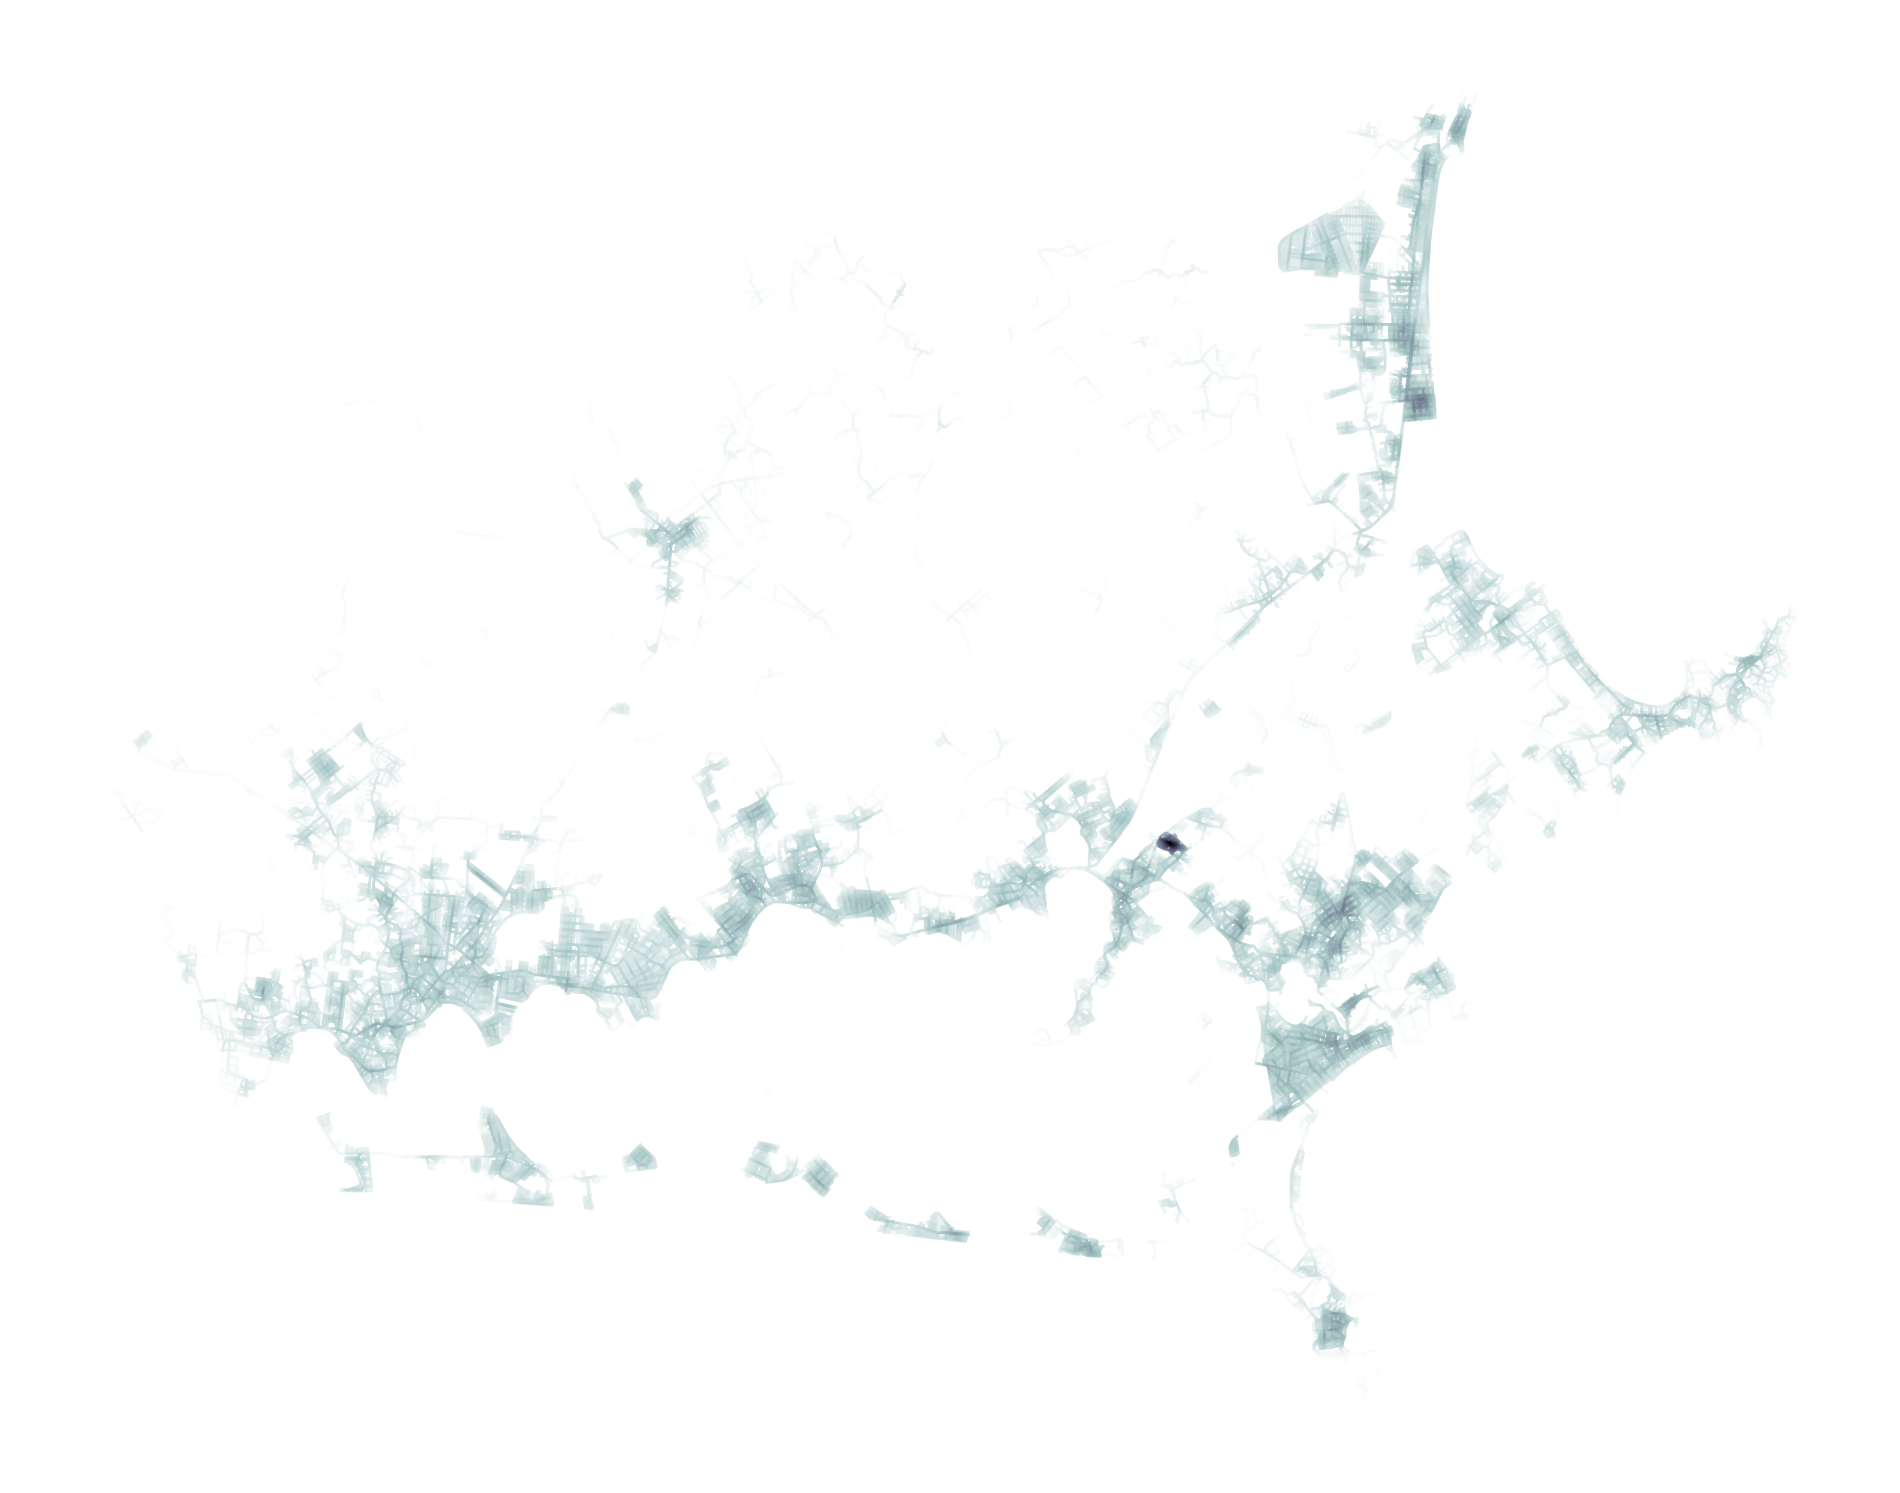

In [176]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_hillier_500_ang"
nodes_gdf.sort_values(metric).plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="bone_r",
    #cmap='inferno',
    legend=False,
    #scheme='JenksCaspall',
    ax=ax,
    linewidth=1,
)

ax.axis(False)

plt.show()

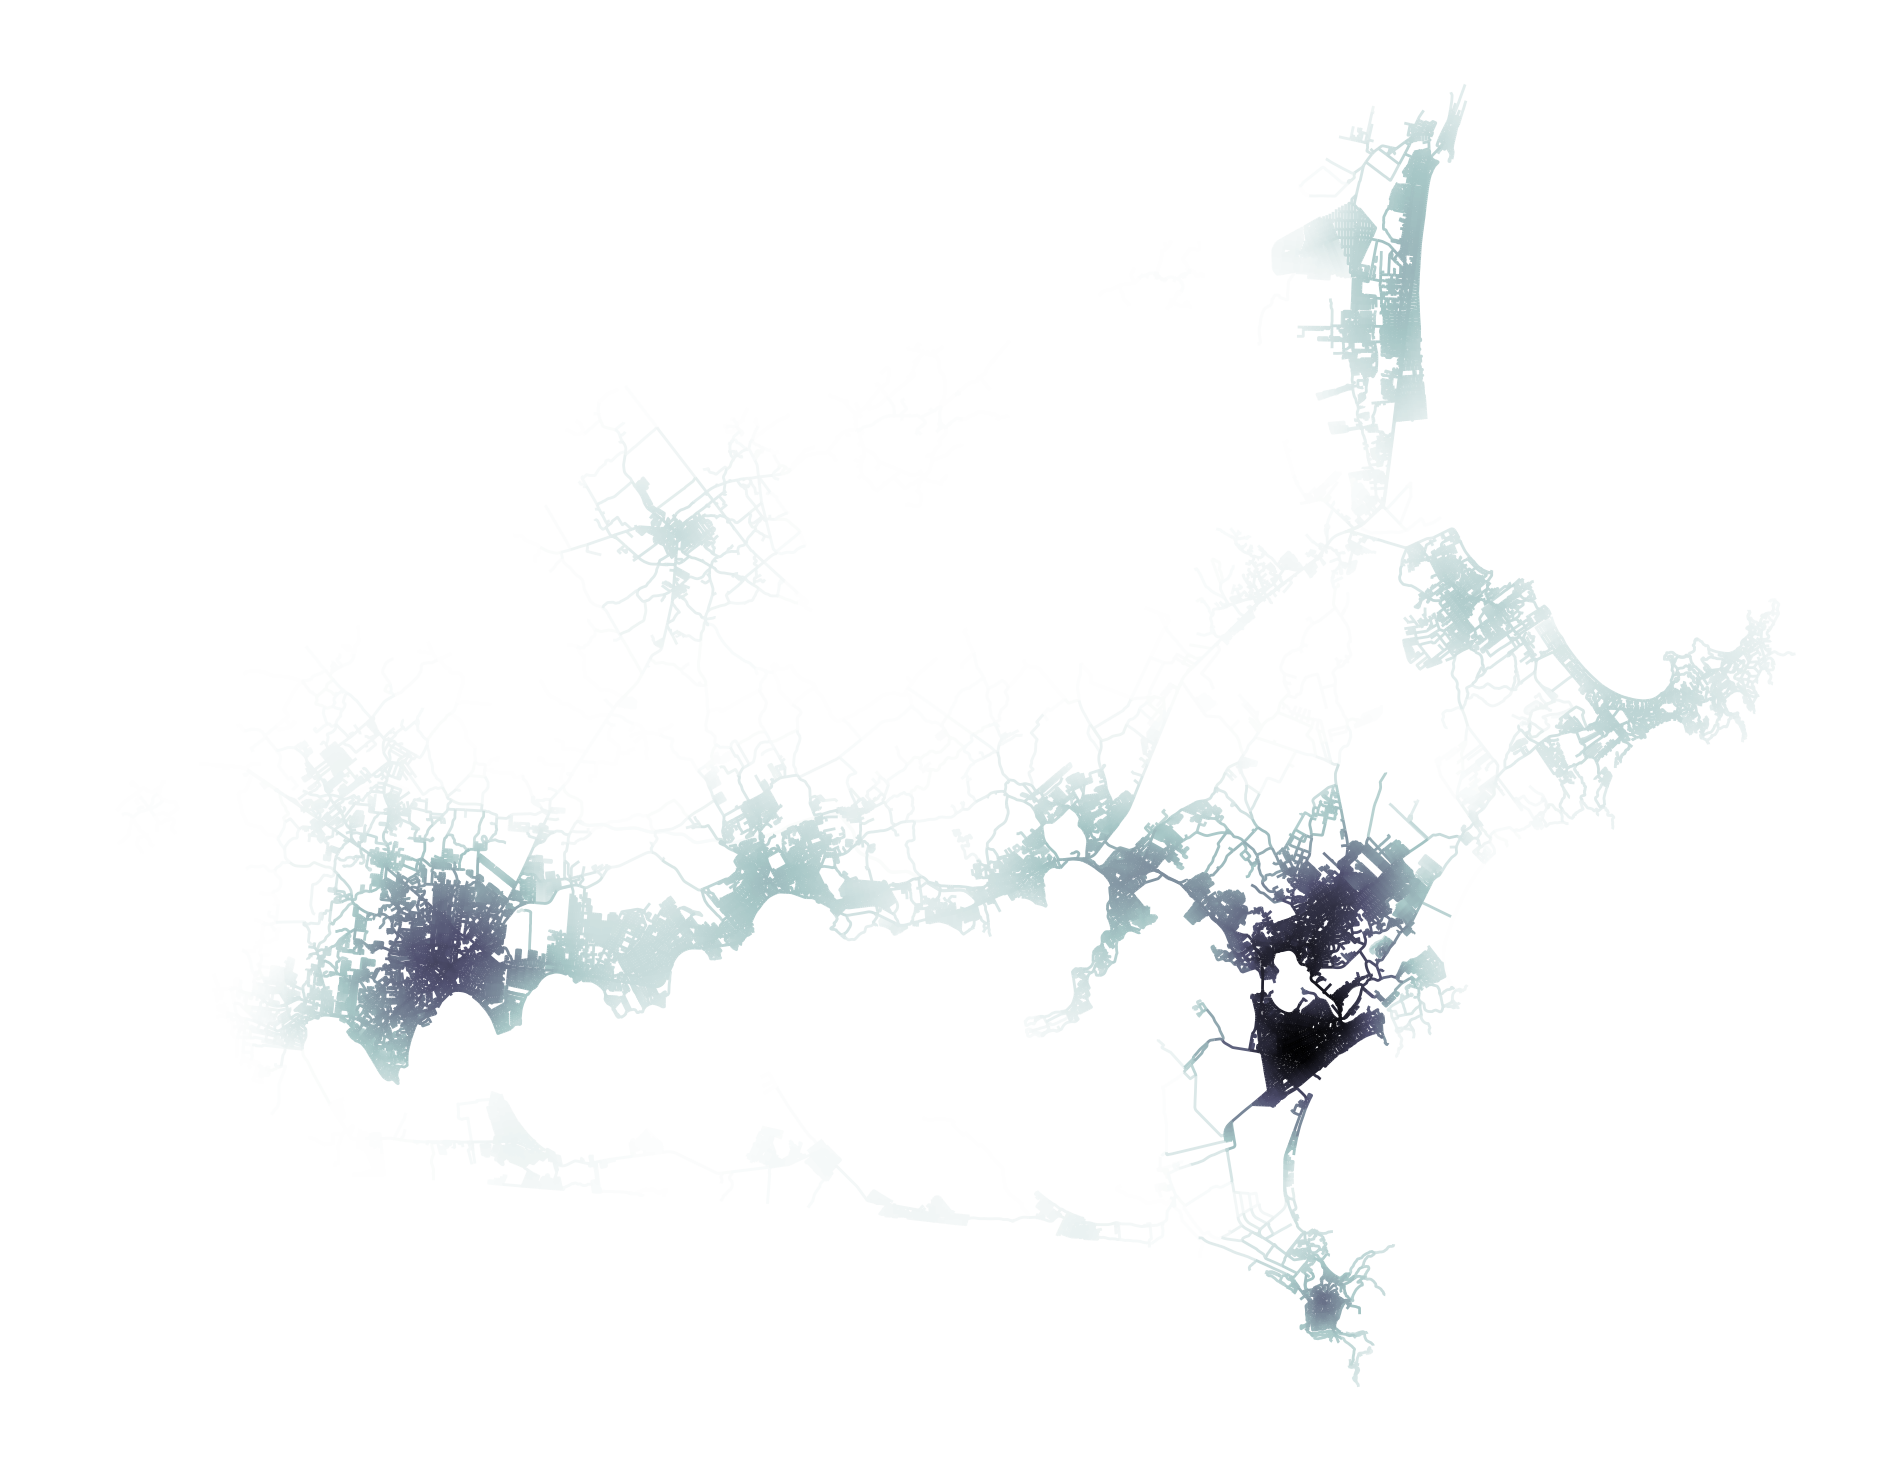

In [163]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_hillier_5000"
weighted_nodes_gdf.sort_values(metric).plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="bone_r",
    #cmap='inferno',
    legend=False,
    #scheme='JenksCaspall',
    ax=ax,
    linewidth=1,
)

ax.axis(False)

plt.show()

In [134]:
weighted_nodes_gdf.filter(like='cc').columns

Index(['cc_beta_500', 'cc_beta_1000', 'cc_beta_1500', 'cc_beta_2000',
       'cc_beta_2500', 'cc_beta_5000', 'cc_beta_10000', 'cc_cycles_500',
       'cc_cycles_1000', 'cc_cycles_1500', 'cc_cycles_2000', 'cc_cycles_2500',
       'cc_cycles_5000', 'cc_cycles_10000', 'cc_density_500',
       'cc_density_1000', 'cc_density_1500', 'cc_density_2000',
       'cc_density_2500', 'cc_density_5000', 'cc_density_10000',
       'cc_farness_500', 'cc_farness_1000', 'cc_farness_1500',
       'cc_farness_2000', 'cc_farness_2500', 'cc_farness_5000',
       'cc_farness_10000', 'cc_harmonic_500', 'cc_harmonic_1000',
       'cc_harmonic_1500', 'cc_harmonic_2000', 'cc_harmonic_2500',
       'cc_harmonic_5000', 'cc_harmonic_10000', 'cc_hillier_500',
       'cc_hillier_1000', 'cc_hillier_1500', 'cc_hillier_2000',
       'cc_hillier_2500', 'cc_hillier_5000', 'cc_hillier_10000',
       'cc_betweenness_500', 'cc_betweenness_1000', 'cc_betweenness_1500',
       'cc_betweenness_2000', 'cc_betweenness_2500', 'cc_

## GTFS Centralities

In [58]:
# For keeping track of the centrality without GTFS
new_cols = {}
for col in weighted_nodes_gdf.columns:
    if col.startswith("cc_"):
        new_cols[f"{col}_not"] = weighted_nodes_gdf[col]

weighted_nodes_gdf = pd.concat(
    [
        weighted_nodes_gdf,
        pd.DataFrame(new_cols, index=weighted_nodes_gdf.index)
    ],
    axis=1,
    )


In [59]:
from pyproj import Transformer

input_dir = "../database/4. Dados Operacionais do Transporte/GTFS"
inpath = f"{input_dir}/gtfs_intermunicipal_leste_morning_peak.zip"

with tempfile.TemporaryDirectory() as tmpdir:
    with zipfile.ZipFile(inpath, 'r') as zf:
        zf.extractall(tmpdir)

    gtfs_data_path = tmpdir
    gtfs_path = Path(gtfs_data_path)
    
    if not gtfs_path.exists():
        raise FileNotFoundError(f"GTFS data not found at {gtfs_data_path}")
    if not (gtfs_path / "stops.txt").exists():
        raise FileNotFoundError(f"GTFS stops.txt not found at {gtfs_data_path}")
    if not (gtfs_path / "stop_times.txt").exists():
        raise FileNotFoundError(f"GTFS stop_times.txt not found at {gtfs_data_path}")
    
    # load GTFS stops data - rename stop_id to include gtfs_data_path
    stops = pd.read_csv(gtfs_path / "stops.txt")
    
    # load GTFS stop times data - rename stop_id to include gtfs_data_path
    stop_times = pd.read_csv(gtfs_path / "stop_times.txt")
    

    # prepare arrival time
    stop_times["arrival_time"] = pd.to_datetime(stop_times["arrival_time"], format="%H:%M:%S").dt.time
    stop_times["arrival_seconds"] = stop_times["arrival_time"].apply(lambda t: t.hour * 3600 + t.minute * 60 + t.second)
    stop_times.sort_values(by=["stop_id", "arrival_seconds"], inplace=True)
    
    # compute gaps between consecutive arrivals
    stop_times["wait_time"] = stop_times.groupby("stop_id")["arrival_seconds"].diff()
    
    # average wait time at stations
    avg_wait_time = stop_times.groupby("stop_id")["wait_time"].mean().fillna(0)
    avg_wait_time = avg_wait_time / 2
    
    # merge avg_wait_time into stop times data
    stops = stops.merge(avg_wait_time.rename("avg_wait_time"), on="stop_id", how="left")
    
    # transformer to convert lat/lon to graph crs
    network_crs = nodes_gdf.crs
    transformer = Transformer.from_crs(4326, network_crs, always_xy=True)

    # Add GTFS stops as transport nodes, using add_transport_node with linking_radius and speed_m_s
    stop_idx_map = {}
    for _, row in tqdm(stops.iterrows(), total=len(stops)):
        e, n = transformer.transform(row["stop_lon"], row["stop_lat"])
        ns_node_idx = network_structure.add_transport_node(
            row["stop_id"],
            float(e),
            float(n),
            linking_radius=400,  # meters
        )
        stop_idx_map[row["stop_id"]] = ns_node_idx

    # sort stop_times for proper sequencing
    stop_times.sort_values(by=["trip_id", "stop_sequence"], inplace=True)
    stop_times["prev_stop_id"] = stop_times.groupby("trip_id")["stop_id"].shift()
    
    # compute travel time between consecutive stops
    stop_times["segment_time"] = stop_times.groupby("trip_id")["arrival_seconds"].diff()
    # rename stop_id to next_stop_id
    stop_times.rename(columns={"stop_id": "next_stop_id"}, inplace=True)
    # average segment time between consecutive stops
    avg_stop_pairs = (
        stop_times.dropna(subset=["prev_stop_id"])  # remove rows where prev_stop_id is NaN
        .groupby(["prev_stop_id", "next_stop_id"])["segment_time"]
        .mean()
        .reset_index(name="avg_segment_time")
    )

    for _, row in tqdm(avg_stop_pairs.iterrows(), total=len(avg_stop_pairs)):
        prev_stop = row["prev_stop_id"]
        next_stop = row["next_stop_id"]
        if prev_stop not in stop_idx_map or next_stop not in stop_idx_map:
            continue
        prev_stop_idx = stop_idx_map[prev_stop]
        next_stop_idx = stop_idx_map[next_stop]
        avg_seg_time = row["avg_segment_time"]
        # Add edge (forward)
        _edge_idx = network_structure.add_transport_edge(
            prev_stop_idx,
            next_stop_idx,
            0,  # edge_idx
            "na-gtfs",
            "na-gtfs",
            float(avg_seg_time),
            None,
        )
        # Add edge (reverse)
        _edge_idx = network_structure.add_transport_edge(
            next_stop_idx,
            prev_stop_idx,
            0,
            "na-gtfs",
            "na-gtfs",
            float(avg_seg_time),
            None,
        )

    network_structure.validate()
    network_structure.build_edge_rtree()

100%|██████████| 17782/17782 [00:01<00:00, 14222.38it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 87106 items.


In [20]:
stops.avg_wait_time.describe()
# count nan
stops.avg_wait_time.isna().sum()
# impute

268

In [60]:
weighted_nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances, 
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 40370/40370 [22:57<00:00, 29.30it/s]   
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.


In [61]:
weighted_nodes_gdf = networks.node_centrality_simplest(
    network_structure=network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances, 
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 40370/40370 [03:29<00:00, 192.96it/s] 
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.


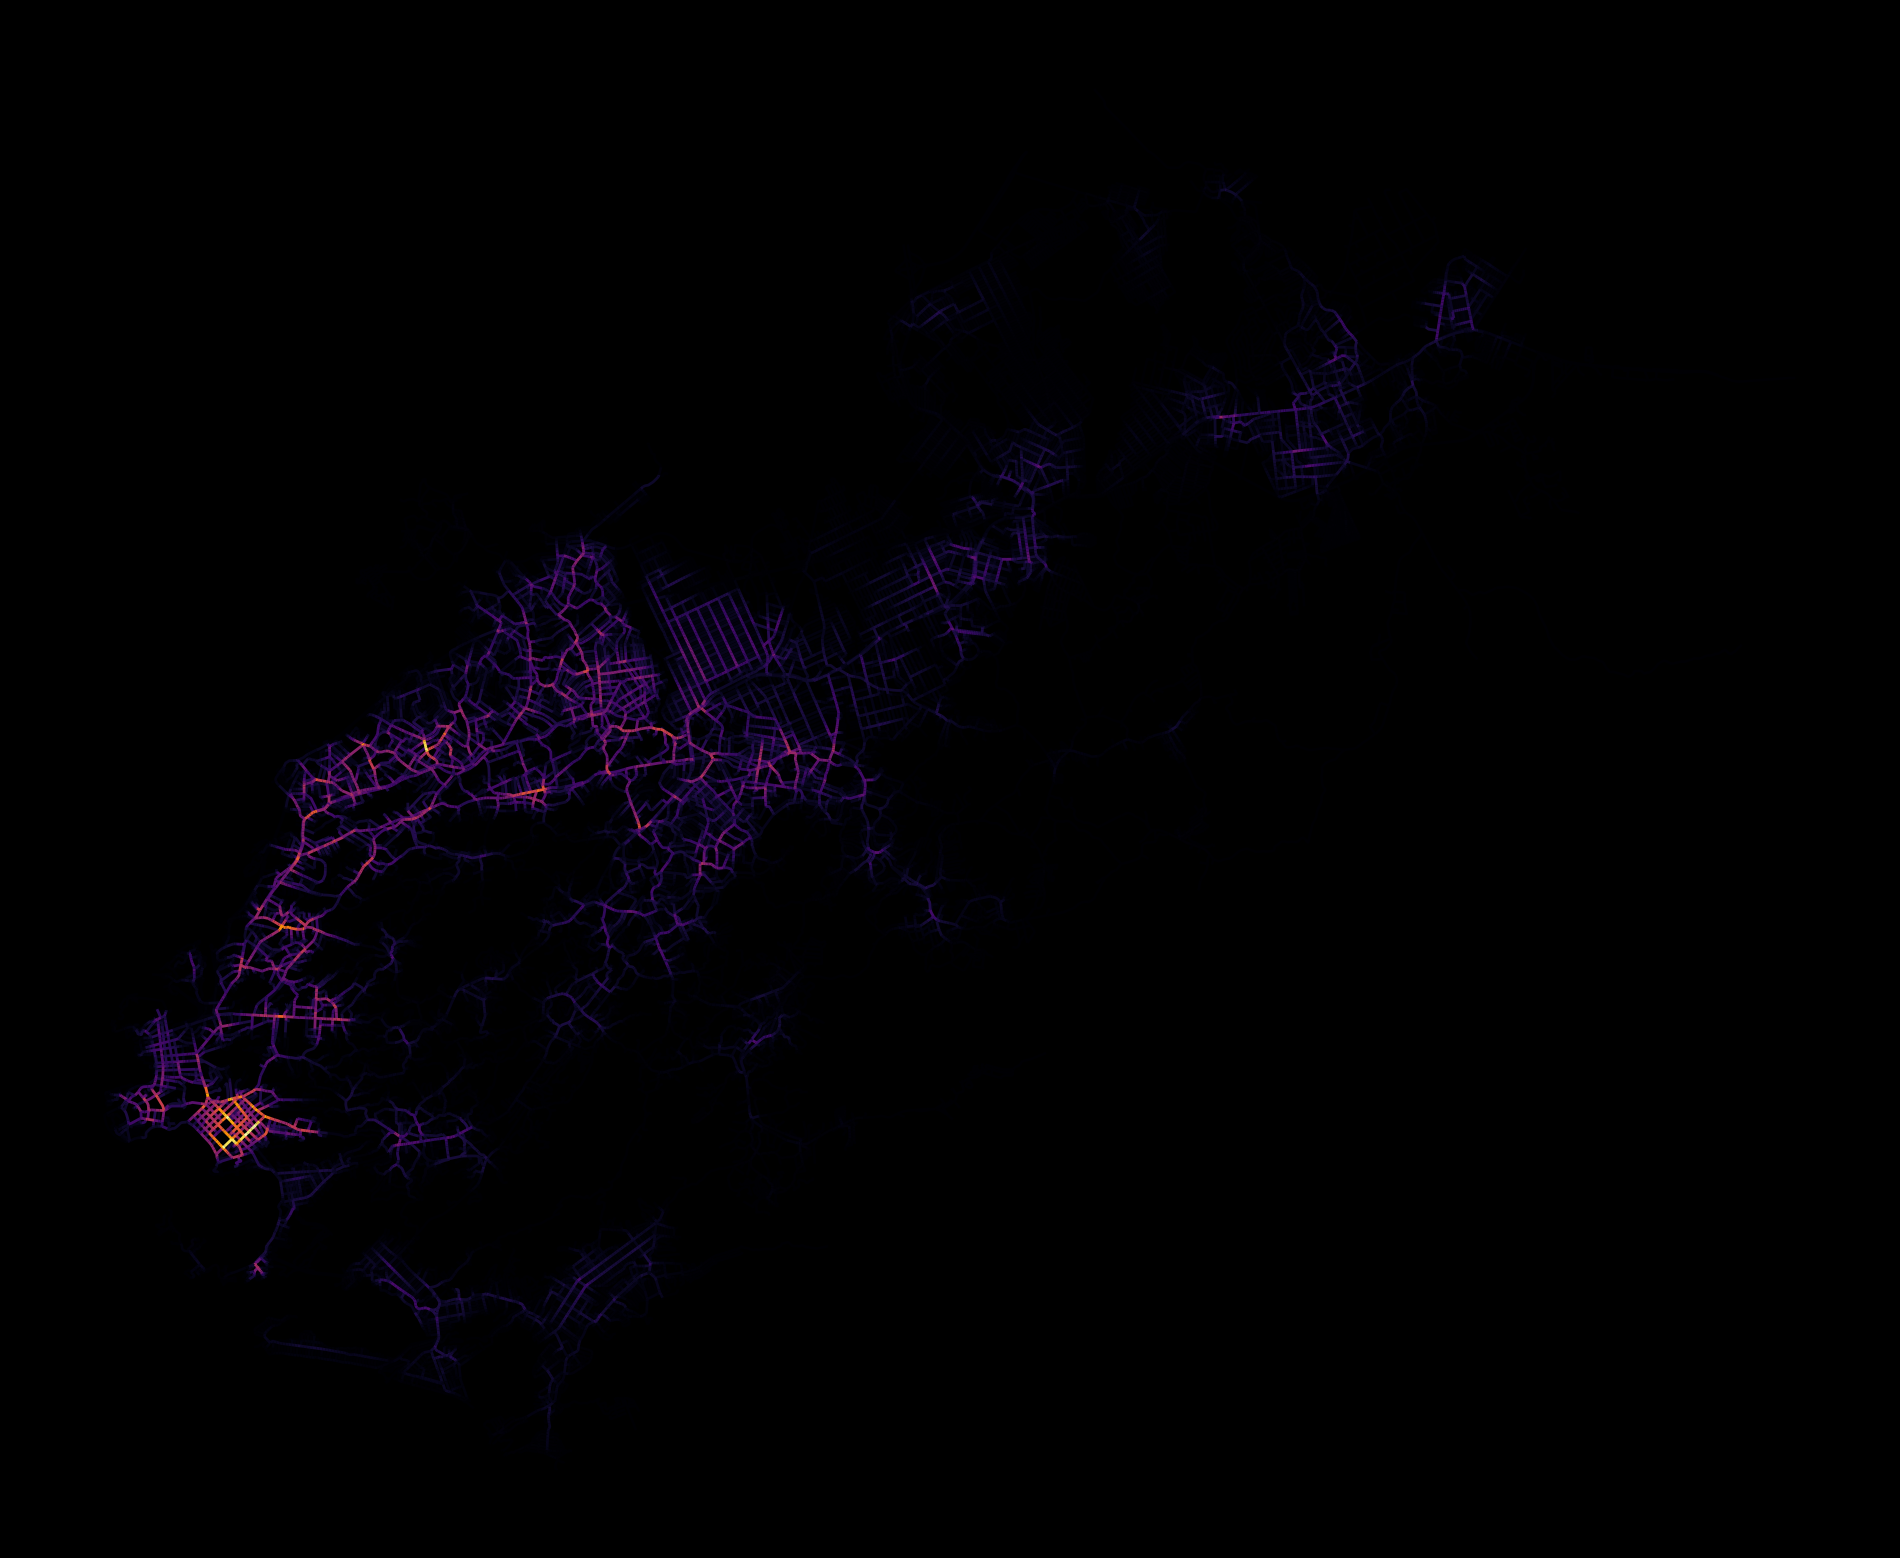

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#000000")

metric = "cc_betweenness_1000_ang_not"
weighted_nodes_gdf.sort_values(metric).plot(
    column=metric,
    #cmap="PuBuGn",
    cmap='inferno',
    legend=False,
    #scheme='JenksCaspall',
    ax=ax,
    linewidth=1,
)

ax.axis(False)

plt.show()

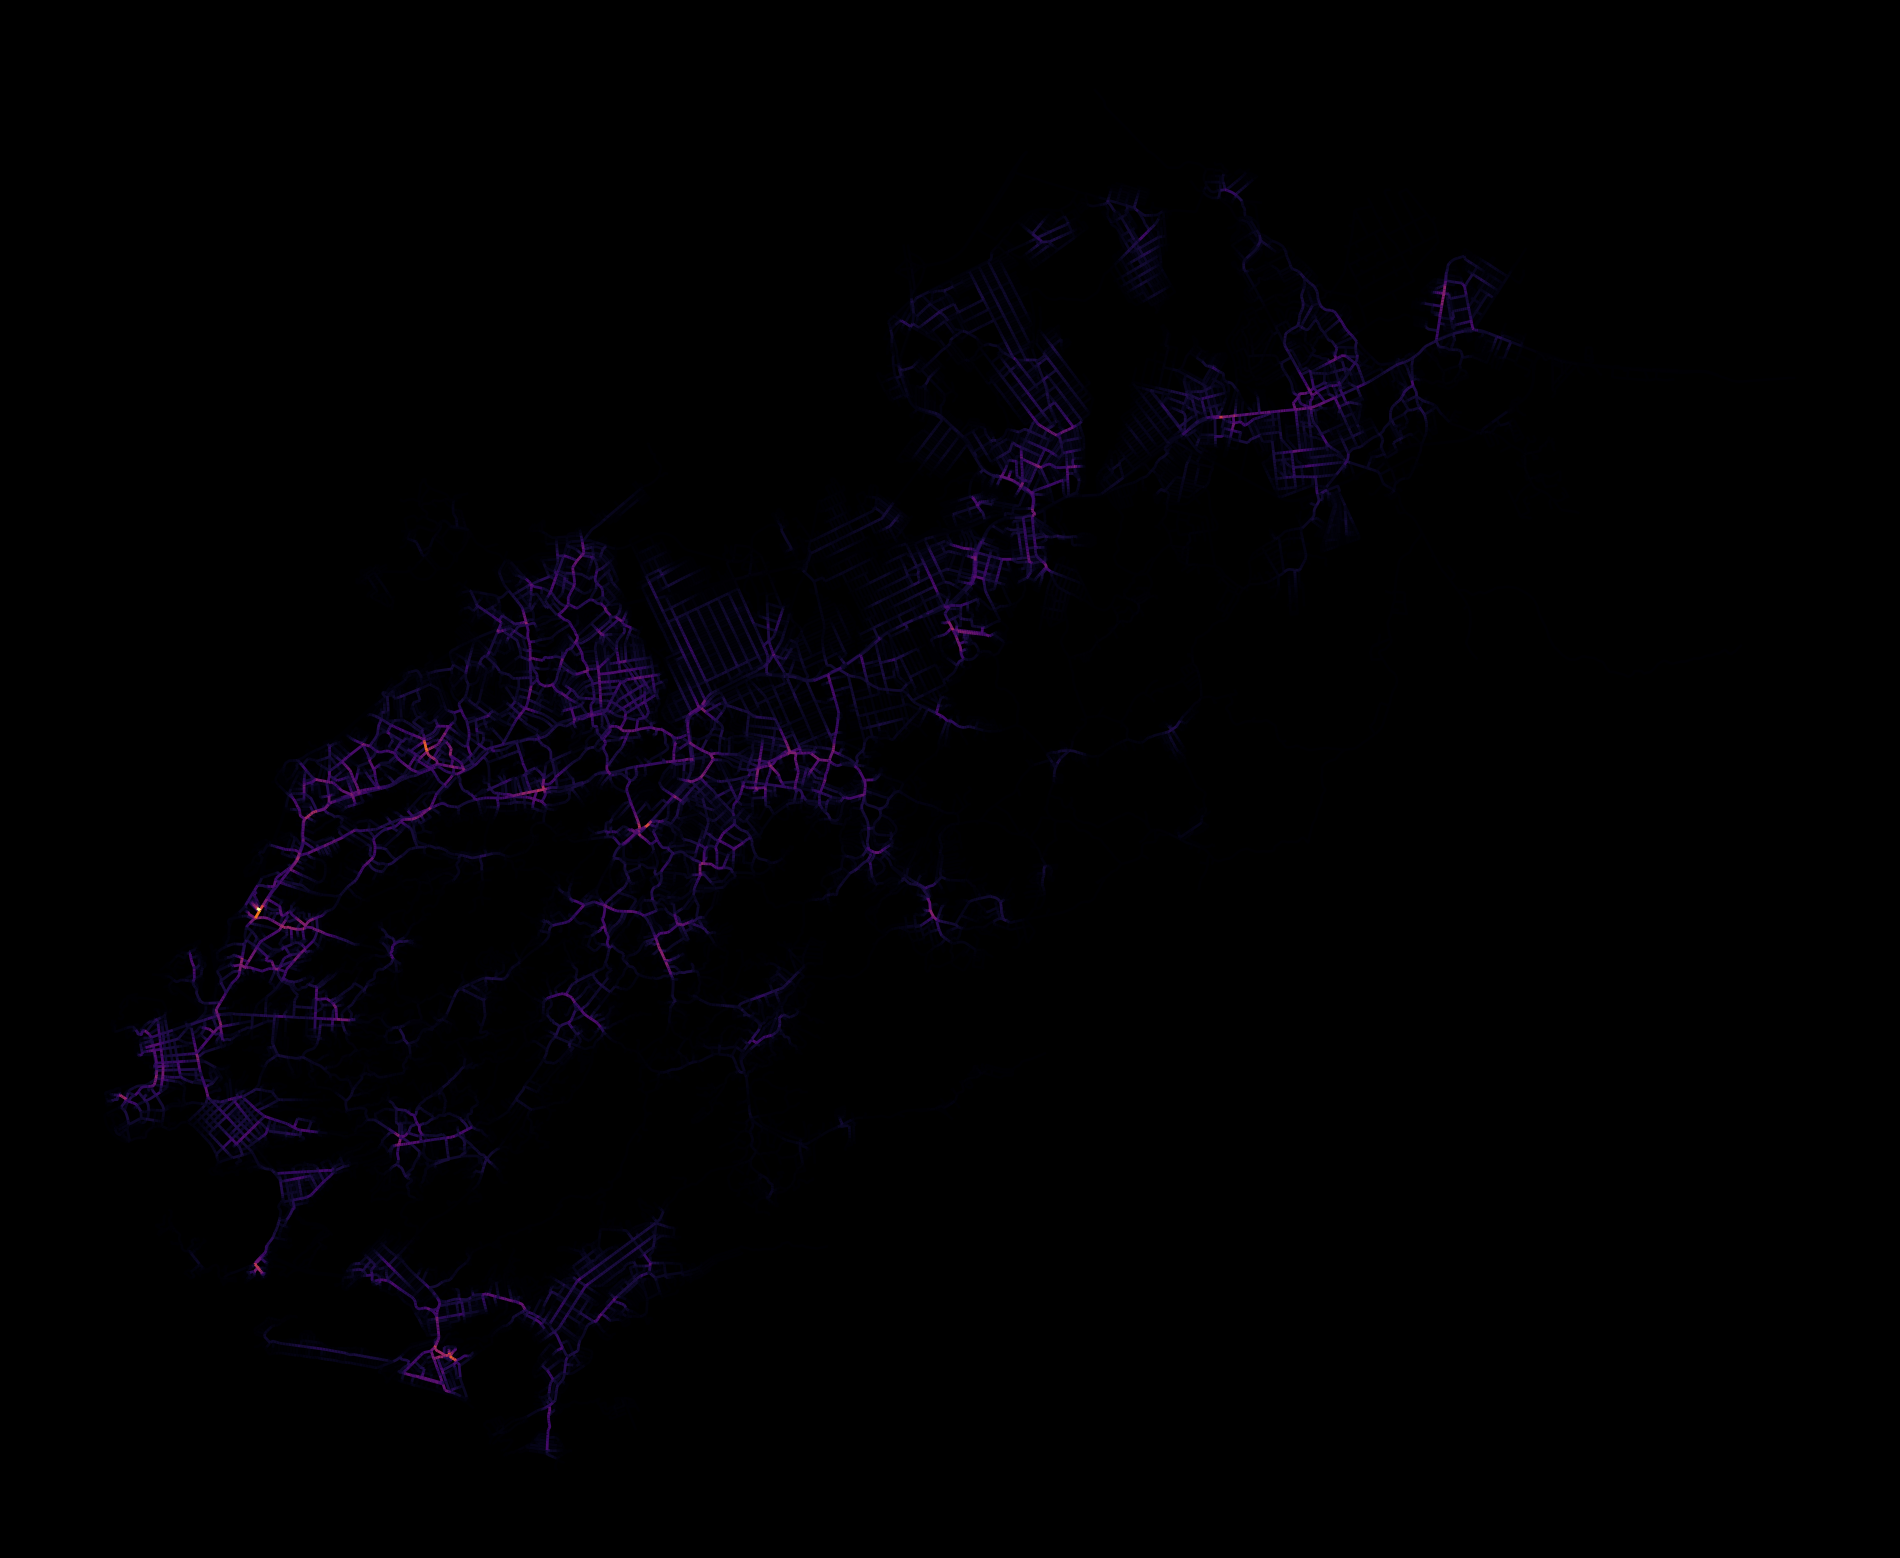

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#000000")

metric = "cc_betweenness_1000_ang"
nodes_gdf.sort_values(metric).plot(
    column=metric,
    #cmap="PuBuGn",
    cmap='inferno',
    legend=False,
    #scheme='JenksCaspall',
    ax=ax,
    linewidth=1,
)

ax.axis(False)

plt.show()

In [ ]:
nodes_gdf = gpd.read_parquet(
    "rio_node_centrality.parquet"
)